# Kinship Library
## Notebook 03: NLP, Semantic Embeddings, K Means, PCA and Recommender

### Purpose

This notebook transforms the processed book catalogue into a working semantic recommendation system.

It uses two complementary NLP approaches.

First, TF IDF provides an interpretable baseline based on words and phrases.

Second, a Sentence Transformer creates semantic embeddings that can connect a reader's expressed need with books whose descriptions and subjects have related meaning.

### Input

`data/processed/books_enriched.csv`

### Outputs

`data/processed/books_model_ready.csv`

`models/book_embeddings.npy`

`models/book_clusters.csv`

### Main workflow

1. Load the enriched catalogue.
2. Select NLP eligible books.
3. Create a TF IDF baseline.
4. Generate transformer based semantic embeddings.
5. Explore K Means with Elbow and Silhouette.
6. Visualize the semantic space with PCA.
7. Build book to book recommendations.
8. Build need based recommendations such as fear of the future, eco anxiety, disconnection from nature and search for meaning.

## 1. Setup

### Purpose

Mount Google Drive, load the libraries and define permanent project paths.

### Expected result

The enriched catalogue from Notebook 02 should be found.

In [ ]:
from google.colab import drive
from pathlib import Path

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/kinship_library")
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
MODELS = PROJECT_ROOT / "models"

MODELS.mkdir(parents=True, exist_ok=True)

ENRICHED_FILE = PROCESSED_DATA / "books_enriched.csv"
MODEL_READY_FILE = PROCESSED_DATA / "books_model_ready.csv"
EMBEDDINGS_FILE = MODELS / "book_embeddings.npy"
CLUSTERS_FILE = MODELS / "book_clusters.csv"

RANDOM_STATE = 42

print("Enriched catalogue exists:", ENRICHED_FILE.exists())

Mounted at /content/drive
Enriched catalogue exists: True


## 2. Load the enriched catalogue

### Purpose

Load the permanent output from Notebook 02.

### Expected result

The catalogue should contain 925 books.

In [ ]:
books_enriched = pd.read_csv(ENRICHED_FILE)

print("Books loaded:", len(books_enriched))

display(
    books_enriched[
        [
            "title",
            "author",
            "collection_theme",
            "semantic_text_words",
            "nlp_text_quality"
        ]
    ].head()
)

Books loaded: 925


,title,author,collection_theme,semantic_text_words,nlp_text_quality
0,The ecology of human development,Urie Bronfenbrenner,humans_and_nature,66,rich
1,People and nature,Emilio F. Moran,humans_and_nature,49,rich
2,The green imperative,"Victor J. Papanek, Victor Papanek",humans_and_nature,240,rich
3,Design with nature,Ian L. McHarg,humans_and_nature,78,rich
4,"The death of nature: women, ecology, and the s...",Carolyn Merchant,humans_and_nature,55,rich


## 3. Select NLP eligible books

### Purpose

Keep the full catalogue intact, but create a modeling subset with at least 15 words of semantic text.

This threshold was selected after the text quality analysis in Notebook 02.

### Expected result

Based on the previous analysis, approximately 713 books should remain.

In [ ]:
model_books = books_enriched[
    books_enriched["semantic_text_words"] >= 15
].copy()

model_books = model_books.reset_index(drop=True)

print("Full catalogue:", len(books_enriched))
print("NLP eligible books:", len(model_books))
print(
    "Percentage retained:",
    round(len(model_books) / len(books_enriched) * 100, 2),
    "%"
)

display(
    model_books["collection_theme"]
    .value_counts()
    .to_frame("books")
)

Full catalogue: 925
NLP eligible books: 713
Percentage retained: 77.08 %


,books
collection_theme,
indigenous_knowledge_americas,335
humans_and_nature,149
yoga_philosophy,86
ayurveda_indian_spirituality,80
yoga_way_of_life,63


## 4. Basic text cleaning for TF IDF

### Purpose

Create a lightly cleaned version of `semantic_text`.

For TF IDF we lowercase the text, remove HTML fragments and remove punctuation.

For transformer embeddings we will use the original `semantic_text` because transformer models benefit from natural language structure.

In [ ]:
def clean_text_for_tfidf(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )

    text = re.sub(
        r"[^a-z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


model_books["tfidf_text"] = (
    model_books["semantic_text"]
    .apply(clean_text_for_tfidf)
)

display(
    model_books[
        ["title", "tfidf_text"]
    ].head()
)

,title,tfidf_text
0,The ecology of human development,the ecology of human development urie bronfenb...
1,People and nature,people and nature emilio f moran effect of env...
2,The green imperative,the green imperative victor j papanek victor p...
3,Design with nature,design with nature ian l mcharg effect of envi...
4,"The death of nature: women, ecology, and the s...",the death of nature women ecology and the scie...


# Part A: TF IDF baseline

## 5. Create TF IDF vectors

### Purpose

Build an interpretable NLP baseline.

TF IDF represents books according to important words and two word phrases.

This baseline helps us compare lexical similarity with transformer based semantic similarity.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    model_books["tfidf_text"]
)

print("TF IDF matrix shape:", tfidf_matrix.shape)

TF IDF matrix shape: (713, 5000)


## 6. Inspect important TF IDF terms

### Purpose

Check whether the vocabulary reflects the themes of Kinship Library.

In [ ]:
feature_names = np.array(
    tfidf_vectorizer.get_feature_names_out()
)

mean_tfidf = np.asarray(
    tfidf_matrix.mean(axis=0)
).ravel()

top_indices = mean_tfidf.argsort()[-30:][::-1]

top_terms = pd.DataFrame({
    "term": feature_names[top_indices],
    "mean_tfidf": mean_tfidf[top_indices]
})

display(top_terms)

,term,mean_tfidf
0,yoga,0.035297
1,indians,0.029121
2,environmental,0.028524
3,human,0.028124
4,social,0.026026
5,indigenous,0.024268
6,ecology,0.023608
7,knowledge,0.023361
8,nature,0.022569
9,philosophy,0.020605


## 7. TF IDF book recommendation baseline

### Purpose

Test a simple book to book recommender based on shared words and phrases.

In [ ]:
tfidf_similarity = cosine_similarity(
    tfidf_matrix
)


def recommend_tfidf(title, n=5):

    matches = model_books[
        model_books["title"]
        .str.lower()
        .eq(title.lower())
    ]

    if matches.empty:
        print("Title not found.")
        return pd.DataFrame()

    idx = matches.index[0]

    scores = list(
        enumerate(
            tfidf_similarity[idx]
        )
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    scores = [
        item
        for item in scores
        if item[0] != idx
    ][:n]

    result_indices = [
        item[0]
        for item in scores
    ]

    result = model_books.loc[
        result_indices,
        [
            "title",
            "author",
            "collection_theme"
        ]
    ].copy()

    result["similarity"] = [
        round(item[1], 3)
        for item in scores
    ]

    return result.reset_index(drop=True)

In [ ]:
# Example

seed_title = model_books.iloc[0]["title"]

print("Seed book:", seed_title)

display(
    recommend_tfidf(
        seed_title,
        n=5
    )
)

Seed book: The ecology of human development


,title,author,collection_theme,similarity
0,Understanding child abuse and neglect,Cynthia Crosson-Tower,indigenous_knowledge_americas,0.199
1,Learning endogenous development,COMPAS (Project),indigenous_knowledge_americas,0.198
2,Participating in development,"Paul Sillitoe, Alan Bicker, Johan Pottier",indigenous_knowledge_americas,0.195
3,Anthropocene Psychology,Matthew Adams,humans_and_nature,0.176
4,Religion and development in southern and centr...,"Religion, Citizenship and Development -- South...",indigenous_knowledge_americas,0.170


# Part B: Transformer based semantic embeddings

## 8. Install Sentence Transformers

### Purpose

Use a model specifically trained to create comparable sentence and document embeddings.

This is more appropriate for semantic recommendation than using raw RoBERTa token outputs directly.

### Note

The first execution downloads the pretrained model from Hugging Face. Later executions in a fresh Colab runtime may need to download it again.

In [ ]:
!pip -q install sentence-transformers

## 9. Load the semantic embedding model

### Purpose

Use a compact Sentence Transformer that performs well for semantic similarity while remaining practical for a student Colab project.

We use `all-MiniLM-L6-v2`.

The model produces one numerical vector for each book.

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Sentence Transformer loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence Transformer loaded.


## 10. Generate or load book embeddings

### Purpose

Create semantic vectors for every NLP eligible book.

The vectors are saved permanently to Google Drive. If the file already exists with the correct number of rows, it is loaded instead of recalculated.

### Expected result

The embedding matrix should have one row per NLP eligible book.

In [ ]:
if EMBEDDINGS_FILE.exists():

    book_embeddings = np.load(
        EMBEDDINGS_FILE
    )

    if len(book_embeddings) == len(model_books):

        print(
            "Loaded saved embeddings:",
            book_embeddings.shape
        )

    else:

        print(
            "Saved embeddings do not match current catalogue."
        )

        book_embeddings = embedding_model.encode(
            model_books["semantic_text"].tolist(),
            batch_size=32,
            show_progress_bar=True,
            normalize_embeddings=True
        )

        np.save(
            EMBEDDINGS_FILE,
            book_embeddings
        )

else:

    book_embeddings = embedding_model.encode(
        model_books["semantic_text"].tolist(),
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True
    )

    np.save(
        EMBEDDINGS_FILE,
        book_embeddings
    )

    print(
        "Embeddings saved:",
        EMBEDDINGS_FILE
    )


print(
    "Embedding matrix shape:",
    book_embeddings.shape
)

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Embeddings saved: /content/drive/MyDrive/kinship_library/models/book_embeddings.npy
Embedding matrix shape: (713, 384)


## 11. Inspect semantic similarity

### Purpose

Test whether the transformer can retrieve books that are semantically related even when they do not use exactly the same words.

In [12]:
def recommend_semantic_book(title, n=5):

    matches = model_books[
        model_books["title"]
        .str.lower()
        .eq(title.lower())
    ]

    if matches.empty:
        print("Title not found.")
        return pd.DataFrame()

    idx = matches.index[0]

    query_embedding = (
        book_embeddings[idx]
        .reshape(1, -1)
    )

    similarities = cosine_similarity(
        query_embedding,
        book_embeddings
    )[0]

    ranked_indices = (
        similarities
        .argsort()[::-1]
    )

    ranked_indices = [
        i
        for i in ranked_indices
        if i != idx
    ][:n]

    result = model_books.loc[
        ranked_indices,
        [
            "title",
            "author",
            "collection_theme",
            "description_final"
        ]
    ].copy()

    result["similarity"] = [
        round(similarities[i], 3)
        for i in ranked_indices
    ]

    return result.reset_index(drop=True)

In [13]:
# Example

seed_title = model_books.iloc[0]["title"]

print("Seed book:", seed_title)

display(
    recommend_semantic_book(
        seed_title,
        n=5
    )
)

Seed book: The ecology of human development


,title,author,collection_theme,description_final,similarity
0,Ecology,David T. Krohne,humans_and_nature,This text provides students and instructors wi...,0.562
1,Human ecology,Bernard Grant Campbell,humans_and_nature,Biologically as well as culturally sophisticat...,0.525
2,"Connection to Nature, Deep Ecology, and Conser...","Christian Diehm, Holmes Rolston III",humans_and_nature,"In Connection to Nature, Deep Ecology, and Con...",0.503
3,Ecological Transition,John W. Bennett,humans_and_nature,Written during the height of the ecology movem...,0.498
4,Human Ecology,Gerald G. Marten,humans_and_nature,'The scope and clarity of this book make it ac...,0.489


“TF IDF provided my baseline and found books through shared vocabulary. Transformer embeddings produced a more conceptually coherent neighborhood by representing the meaning of the book metadata. For the same seed book, semantic similarities increased from approximately 0.2 to around 0.5, while the recommendations became much more closely related to ecology and human nature relations.”

# Part C: Unsupervised learning

## 12. Test K Means cluster values

### Purpose

Explore how many broad semantic groups exist in the book embedding space.

We test several values of K using both the Elbow Method and Silhouette Score.

K Means clusters are exploratory. They are not the same as the original collection themes.

In [14]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:

    kmeans_test = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans_test.fit_predict(
        book_embeddings
    )

    inertias.append(
        kmeans_test.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            book_embeddings,
            labels
        )
    )


k_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(k_results)

,k,inertia,silhouette_score
0,2,481.535400,0.096475
1,3,451.286560,0.098287
2,4,438.315247,0.085195
3,5,425.636902,0.070670
4,6,418.192017,0.070912
5,7,412.426758,0.060081
6,8,407.518433,0.068552
7,9,401.211487,0.063257
8,10,397.608276,0.066516


## 13. Elbow Method

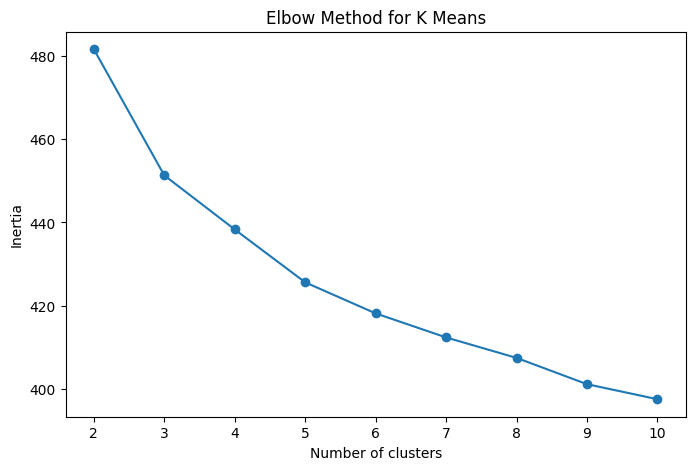

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_results["k"],
    k_results["inertia"],
    marker="o"
)

plt.title(
    "Elbow Method for K Means"
)

plt.xlabel(
    "Number of clusters"
)

plt.ylabel(
    "Inertia"
)

plt.xticks(
    k_results["k"]
)

plt.show()

## 14. Silhouette Score

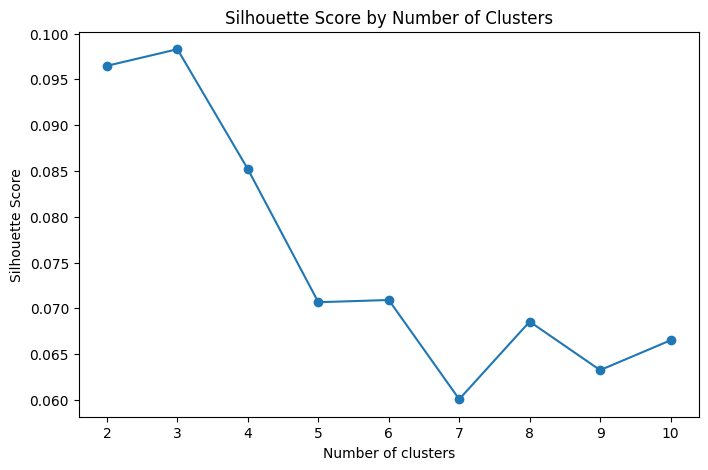

Best K by Silhouette Score: 3


In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_results["k"],
    k_results["silhouette_score"],
    marker="o"
)

plt.title(
    "Silhouette Score by Number of Clusters"
)

plt.xlabel(
    "Number of clusters"
)

plt.ylabel(
    "Silhouette Score"
)

plt.xticks(
    k_results["k"]
)

plt.show()


best_k = int(
    k_results.loc[
        k_results[
            "silhouette_score"
        ].idxmax(),
        "k"
    ]
)

print(
    "Best K by Silhouette Score:",
    best_k
)

K Means suggested three broad semantic regions, although the low Silhouette score indicates substantial overlap between them. This is consistent with the interdisciplinary character of the catalogue.

## 15. Fit the selected K Means model

### Purpose

Assign each NLP eligible book to an exploratory semantic cluster.

In [17]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

model_books["cluster"] = (
    kmeans.fit_predict(
        book_embeddings
    )
)

display(
    model_books["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("books")
)

,books
cluster,
0,310
1,229
2,174


In [18]:
print(best_k)

3


## 16. Compare clusters with collection themes

### Purpose

See whether the data driven clusters resemble the original collection themes or mix books across them.

A mixed cluster can be meaningful because semantic relationships may cross the categories used during collection.

In [19]:
cluster_theme_table = pd.crosstab(
    model_books["cluster"],
    model_books["collection_theme"]
)

display(cluster_theme_table)

collection_theme,ayurveda_indian_spirituality,humans_and_nature,indigenous_knowledge_americas,yoga_philosophy,yoga_way_of_life
cluster,,,,,
0,3,146,159,1,1
1,72,2,9,84,62
2,5,1,167,1,0


## 17. Inspect representative books from each cluster

### Purpose

Understand what each cluster may represent by looking at books nearest to its K Means centroid.

In [20]:
representative_rows = []

for cluster_id in range(best_k):

    cluster_indices = np.where(
        model_books["cluster"].values
        == cluster_id
    )[0]

    centroid = (
        kmeans.cluster_centers_[cluster_id]
        .reshape(1, -1)
    )

    similarities = cosine_similarity(
        centroid,
        book_embeddings[
            cluster_indices
        ]
    )[0]

    top_local = (
        similarities
        .argsort()[::-1][:8]
    )

    top_global = (
        cluster_indices[top_local]
    )

    cluster_books = model_books.loc[
        top_global,
        [
            "title",
            "author",
            "collection_theme"
        ]
    ].copy()

    cluster_books.insert(
        0,
        "cluster",
        cluster_id
    )

    representative_rows.append(
        cluster_books
    )


representative_books = pd.concat(
    representative_rows,
    ignore_index=True
)

display(representative_books)

,cluster,title,author,collection_theme
0,0,Socio-Ecological Systems and Decoloniality,"Deepa Pullanikkatil, Kerry Hughes",indigenous_knowledge_americas
1,0,Introduction to the Environmental Humanities,"J. Andrew Hubbell, John Ryan",humans_and_nature
2,0,Traditional ecological knowledge,"Nancy M. Williams, Graham B. K. Baines",indigenous_knowledge_americas
3,0,"Indigenous knowledge, ecology, and evolutionar...",Raymond John Pierotti,indigenous_knowledge_americas
4,0,Natural Science and Indigenous Knowledge,"Edward A. (Ecology Professor) Johnson, Susan M...",indigenous_knowledge_americas
5,0,Indigenous knowledge and the environment in Af...,"David Malcolm Gordon, Shepard Krech",indigenous_knowledge_americas
6,0,Indigenous environmental knowledge and its tra...,"R. F. Ellen, Alan Bicker",indigenous_knowledge_americas
7,0,Handbook of Indigenous Environmental Knowledge,"Thomas Thornton, Shonil Bhagwat",indigenous_knowledge_americas
8,1,Introduction to Yoga Philosophy,"Ashok Kumar Malhotra, Patañjali",yoga_philosophy
9,1,"Sūtras, Stories and Yoga Philosophy",Daniel Raveh,yoga_philosophy


# Part D: PCA visualization

## 18. Reduce embeddings to two dimensions

### Purpose

PCA reduces the transformer embedding space to two dimensions so the semantic clusters can be visualized.

The two PCA axes are mathematical combinations of the original embedding dimensions. They should not automatically be interpreted as specific concepts.

In [21]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

embedding_2d = pca.fit_transform(
    book_embeddings
)

model_books["pca_1"] = embedding_2d[:, 0]
model_books["pca_2"] = embedding_2d[:, 1]

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

Explained variance: [0.11505607 0.07393377]
Total explained variance: 0.189


## 19. Plot semantic clusters

In [ ]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    model_books["pca_1"],
    model_books["pca_2"],
    c=model_books["cluster"],
    alpha=0.65
)

plt.title(
    "PCA Projection of Semantic Book Embeddings"
)

plt.xlabel(
    "PCA component 1"
)

plt.ylabel(
    "PCA component 2"
)

plt.colorbar(
    scatter,
    label="K Means cluster"
)

plt.show()

# Part E: Need based semantic recommender

## 20. Recommend books from a reader's own words

### Purpose

This is the central Kinship Library feature.

Instead of requiring a reader to know a title or genre, the reader can describe what they are experiencing or seeking.

The text is embedded in the same semantic space as the books and compared using cosine similarity.

### Important

The recommendations are based on semantic similarity to book metadata. They are not medical, psychological or spiritual diagnoses.

In [22]:
def recommend_from_need(
    user_text,
    n=8,
    theme=None
):

    query_embedding = embedding_model.encode(
        [user_text],
        normalize_embeddings=True
    )

    similarities = cosine_similarity(
        query_embedding,
        book_embeddings
    )[0]

    candidate_indices = np.arange(
        len(model_books)
    )

    if theme is not None:

        candidate_indices = model_books.index[
            model_books[
                "collection_theme"
            ].eq(theme)
        ].to_numpy()

    ranked_indices = sorted(
        candidate_indices,
        key=lambda i: similarities[i],
        reverse=True
    )[:n]

    result = model_books.loc[
        ranked_indices,
        [
            "title",
            "author",
            "collection_theme",
            "description_final"
        ]
    ].copy()

    result["similarity"] = [
        round(
            similarities[i],
            3
        )
        for i in ranked_indices
    ]

    return result.reset_index(
        drop=True
    )

## 21. Test the four initial Kinship Library needs

### Purpose

Evaluate whether the semantic model retrieves sensible books for the four reader states that motivated this project.

In [23]:
NEED_STATES = {
    "fear_of_the_future": (
        "I feel afraid about the future and uncertain "
        "about how to live with change, instability and "
        "the unknown. I am looking for wisdom, perspective "
        "and a way to relate to uncertainty."
    ),

    "eco_anxiety": (
        "I feel grief and anxiety about climate change, "
        "ecological destruction and the future of the Earth. "
        "I want to understand how to live with care, hope, "
        "responsibility and connection in a changing world."
    ),

    "disconnection_from_nature": (
        "I feel disconnected from nature and from the living "
        "world around me. I want to recover a sense of kinship "
        "with plants, animals, land, ecosystems and the more "
        "than human world."
    ),

    "search_for_meaning": (
        "I am looking for meaning and a deeper understanding "
        "of life, consciousness, spiritual practice and how "
        "to live with purpose."
    )
}

In [24]:
for need_name, need_text in NEED_STATES.items():

    print()
    print("=" * 70)
    print(
        need_name.replace(
            "_",
            " "
        ).upper()
    )
    print("=" * 70)

    display(
        recommend_from_need(
            need_text,
            n=5
        )
    )


FEAR OF THE FUTURE


,title,author,collection_theme,description_final,similarity
0,Upanishads,Eknath Easwaran,ayurveda_indian_spirituality,The Upanishads: one of three new editions of t...,0.364
1,The Upanishads,NaN,yoga_philosophy,The Upanishads: one of three new editions of t...,0.350
2,Resilience Through Knowledge Co-Production,"Marie Roué, Douglas Nakashima, Igor Krupnik",indigenous_knowledge_americas,Collaborative exploration of global environmen...,0.344
3,Planning connections,N. J. Pointner,humans_and_nature,You are about to read a book that was designed...,0.343
4,The primordial bond,Stephen H. Schneider,humans_and_nature,Does the solution to our energy crisis depend ...,0.342



ECO ANXIETY


,title,author,collection_theme,description_final,similarity
0,The good in nature and humanity,"Stephen R. Kellert, Timothy J. Farnham",humans_and_nature,"Scientists, theologians, and the spiritually i...",0.506
1,Climate Change and Indigenous Peoples in the U...,"Julie Koppel Maldonado, Benedict Colombi, Raju...",indigenous_knowledge_americas,With a long history and deep connection to the...,0.503
2,Introduction to the Environmental Humanities,"J. Andrew Hubbell, John Ryan",humans_and_nature,"In an era of climate change, deforestation, me...",0.489
3,Human Ecology,Gerald G. Marten,humans_and_nature,'The scope and clarity of this book make it ac...,0.481
4,Participatory Research in More-Than-Human Worlds,"Michelle Bastian, Owain Jones, Niamh Moore, Em...",humans_and_nature,Socio-environmental crises are currently trans...,0.480



DISCONNECTION FROM NATURE


,title,author,collection_theme,description_final,similarity
0,Awakening to Nature,Charles Cook,humans_and_nature,""" ... Hundred of ideas, thoughts, and suggesti...",0.507
1,Participatory Research in More-Than-Human Worlds,"Michelle Bastian, Owain Jones, Niamh Moore, Em...",humans_and_nature,Socio-environmental crises are currently trans...,0.505
2,Cultural and spiritual values of biodiversity,Darrell A. Posey,indigenous_knowledge_americas,"Weaving together philosophical, historical, le...",0.502
3,Kinship,"Robin Wall Kimmerer, John Hausdoerffer, Gavin ...",indigenous_knowledge_americas,NaN,0.500
4,"Indigenous knowledge, ecology, and evolutionar...",Raymond John Pierotti,indigenous_knowledge_americas,Indigenous ways of understanding and interacti...,0.489



SEARCH FOR MEANING


,title,author,collection_theme,description_final,similarity
0,"Sex, ecology, spirituality",Ken Wilber,humans_and_nature,In this tour de force of scholarship and visio...,0.531
1,Dialogue with death,Eknath Easwaran,yoga_philosophy,Why am I here? Is there a purpose to my life? ...,0.524
2,Buddhism and Deep Ecology,"Daniel H., Ph.D. Henning",humans_and_nature,NaN,0.505
3,Indian Spirituality,Joshua R. Paszkiewicz,ayurveda_indian_spirituality,Nurture your well-being with the eye-opening b...,0.503
4,The Spiritual Quest And the Way of Yoga,Swami Adiswarananda,yoga_way_of_life,Guidance for Your Spiritual Journey—from the W...,0.501


## 22. Test a custom reader query

Change the text below to anything a reader might write in the Streamlit app.

In [25]:
my_need = (
    "I feel disconnected from nature and overwhelmed "
    "by what is happening to the planet. I want books "
    "that can help me recover a sense of relationship, "
    "care and meaning."
)

display(
    recommend_from_need(
        my_need,
        n=8
    )
)

,title,author,collection_theme,description_final,similarity
0,Deep Ecology,"Bill Devall, George Sessions",humans_and_nature,"Deep Ecology explores the philosophical, psych...",0.483
1,The good in nature and humanity,"Stephen R. Kellert, Timothy J. Farnham",humans_and_nature,"Scientists, theologians, and the spiritually i...",0.462
2,Planning connections,N. J. Pointner,humans_and_nature,You are about to read a book that was designed...,0.449
3,Humans and animals,"Julie Urbanik, Connie L. Johnston",indigenous_knowledge_americas,This book takes a look at the coexistence of h...,0.436
4,Buddhism and Deep Ecology,"Daniel H., Ph.D. Henning",humans_and_nature,NaN,0.434
5,Awakening to Nature,Charles Cook,humans_and_nature,""" ... Hundred of ideas, thoughts, and suggesti...",0.429
6,Connected Lives,Ruth E. Groenhout,humans_and_nature,Connected Lives examines the account of human ...,0.424
7,The book of ayurveda,Judith H. Morrison,ayurveda_indian_spirituality,Ayurveda is the system for healthful living ad...,0.414


## 23. Optional thematic filter

### Purpose

Allow the future Streamlit app to combine semantic similarity with a reader selected area.

For example, the same need can be explored specifically through Indigenous Knowledge of the Americas or Yoga Philosophy.

In [26]:
display(
    recommend_from_need(
        my_need,
        n=5,
        theme="indigenous_knowledge_americas"
    )
)

,title,author,collection_theme,description_final,similarity
0,Humans and animals,"Julie Urbanik, Connie L. Johnston",indigenous_knowledge_americas,This book takes a look at the coexistence of h...,0.436
1,African Indigenous Ecological Knowledge Systems,Ikechukwu Anthony Kanu,indigenous_knowledge_americas,The perspectives in this book reveal how in Af...,0.389
2,Spiritual ecology,Leslie E. Sponsel,indigenous_knowledge_americas,A prominent scientist and scholar documents an...,0.385
3,Indigenous knowledge and the environment in Af...,"David Malcolm Gordon, Shepard Krech",indigenous_knowledge_americas,Indigenous knowledge has become a catchphrase ...,0.384
4,The earth's blanket,"Nancy J. Turner, K. Sivaramakrishnan",indigenous_knowledge_americas,Annotation Renowned ethnobotanistNancy Turnerb...,0.384


# Part F: Save model outputs

## 24. Save the modeling catalogue and clusters

### Purpose

Preserve the results for SQL, Streamlit and presentation work without recomputing the entire notebook.

In [27]:
model_books.to_csv(
    MODEL_READY_FILE,
    index=False
)

model_books[
    [
        "source_id",
        "title",
        "author",
        "collection_theme",
        "cluster",
        "pca_1",
        "pca_2"
    ]
].to_csv(
    CLUSTERS_FILE,
    index=False
)

print(
    "Model ready catalogue:",
    MODEL_READY_FILE
)

print(
    "Embeddings:",
    EMBEDDINGS_FILE
)

print(
    "Cluster data:",
    CLUSTERS_FILE
)

print(
    "Model ready file exists:",
    MODEL_READY_FILE.exists()
)

print(
    "Embeddings file exists:",
    EMBEDDINGS_FILE.exists()
)

Model ready catalogue: /content/drive/MyDrive/kinship_library/data/processed/books_model_ready.csv
Embeddings: /content/drive/MyDrive/kinship_library/models/book_embeddings.npy
Cluster data: /content/drive/MyDrive/kinship_library/models/book_clusters.csv
Model ready file exists: True
Embeddings file exists: True


## 25. Final checkpoint

Keep this output for the presentation.

In [28]:
print("KINSHIP LIBRARY NLP CHECKPOINT")
print()

print(
    "Full catalogue:",
    len(books_enriched)
)

print(
    "NLP eligible books:",
    len(model_books)
)

print(
    "TF IDF features:",
    tfidf_matrix.shape[1]
)

print(
    "Embedding dimensions:",
    book_embeddings.shape[1]
)

print(
    "Selected K:",
    best_k
)

print(
    "Semantic clusters:",
    model_books["cluster"].nunique()
)

print()
print(
    "The recommender can now accept "
    "natural language descriptions of a "
    "reader's needs."
)

KINSHIP LIBRARY NLP CHECKPOINT

Full catalogue: 925
NLP eligible books: 713
TF IDF features: 5000
Embedding dimensions: 384
Selected K: 3
Semantic clusters: 3

The recommender can now accept natural language descriptions of a reader's needs.


## The recommender can now accept natural language descriptions of a reader's needs.

\925 books in complete catalogue
        ↓
713 NLP eligible books
        ↓
5,000 TF IDF features
        ↓
384 dimensional semantic embeddings
        ↓
K Means exploration
        ↓
3 semantic clusters
        ↓
Natural language semantic recommender ✓